# Seaborn Statistical, Distribution & Categorical Plotting (5+ Years Interview Guide)
Exhaustive revision guide with dedicated separate cells for histplot, kdeplot, ecdfplot, rugplot, boxplot, violinplot, stripplot, swarmplot, barplot, scatterplot, lineplot, regplot, displot, relplot, and catplot on raw_transactions.csv.

### Key 5-Year Interview Concepts Covered:
- **Distribution Analysis**: Dedicated separate cells for `sns.histplot()`, `sns.kdeplot()`, `sns.ecdfplot()`, and `sns.rugplot()`.
- **Categorical Summaries**: Dedicated separate cells for `sns.boxplot()`, `sns.violinplot()`, `sns.stripplot()`, `sns.swarmplot()`, and `sns.barplot()`.
- **Relationship Mapping**: Dedicated separate cells for `sns.scatterplot()`, `sns.lineplot()`, and `sns.regplot()`.
- **Figure-Level Wrappers**: Dedicated separate cells for `sns.displot()`, `sns.relplot()`, and `sns.catplot()`.

This interactive revision guide uses `data/raw_transactions.csv` with 1-to-1 atomic method cells and rich inline visual outputs.

In [1]:
# Setup imports & dataset loading from raw_transactions.csv
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import sys

# Configure visual aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"Loaded {len(df)} cleaned transaction records from {csv_path}")
print(df.head(2))

Loaded 14262 cleaned transaction records from data/raw_transactions.csv
  transaction_id customer_id merchant_id  ...  transaction_date region is_fraud
0       TX110686      C82845       M2697  ...        2025-07-06  North        0
1       TX107170      C85674       M3868  ...        2025-10-05   East        0

[2 rows x 11 columns]


### Histogram Analysis: `sns.histplot()`
**Explanation**: Plots empirical distribution with automated binning and KDE overlays.

**Syntax**: `sns.histplot(df, x='transaction_amount', hue='card_type', kde=True)`

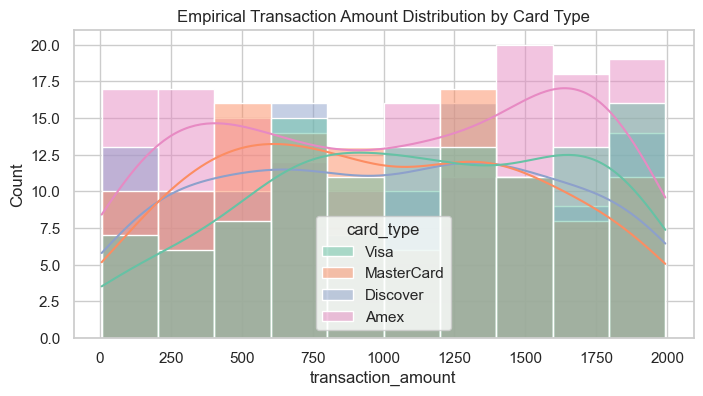

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df.head(500), x='transaction_amount', hue='card_type', kde=True, ax=ax, palette='Set2')
ax.set_title('Empirical Transaction Amount Distribution by Card Type')
plt.show()

### Kernel Density Estimation: `sns.kdeplot()`
**Explanation**: Estimates continuous probability density functions across groups.

**Syntax**: `sns.kdeplot(df, x='transaction_amount', hue='is_fraud', fill=True)`

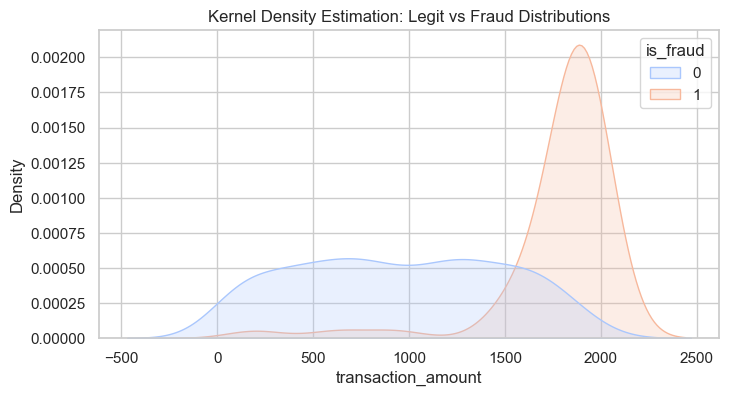

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(df.head(500), x='transaction_amount', hue='is_fraud', fill=True, common_norm=False, palette='coolwarm', ax=ax)
ax.set_title('Kernel Density Estimation: Legit vs Fraud Distributions')
plt.show()

### Cumulative Distributions: `sns.ecdfplot()`
**Explanation**: Calculates empirical cumulative distribution function showing quantile proportions.

**Syntax**: `sns.ecdfplot(df, x='transaction_amount', hue='region')`

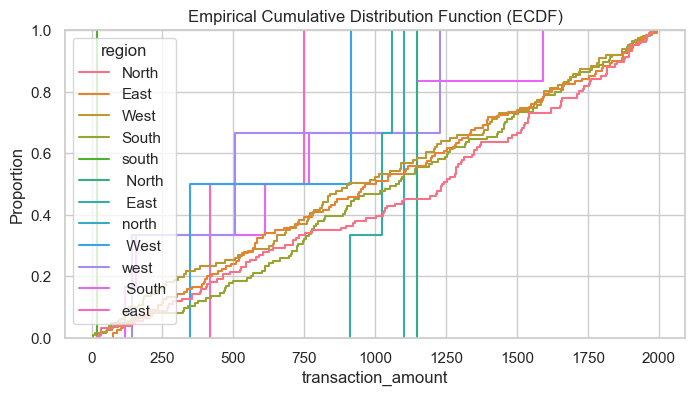

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.ecdfplot(df.head(500), x='transaction_amount', hue='region', ax=ax)
ax.set_title('Empirical Cumulative Distribution Function (ECDF)')
plt.show()

### Marginal Rug Markers: `sns.rugplot()`
**Explanation**: Draws individual data tick markers along the axis margin.

**Syntax**: `sns.rugplot(df['transaction_amount'])`

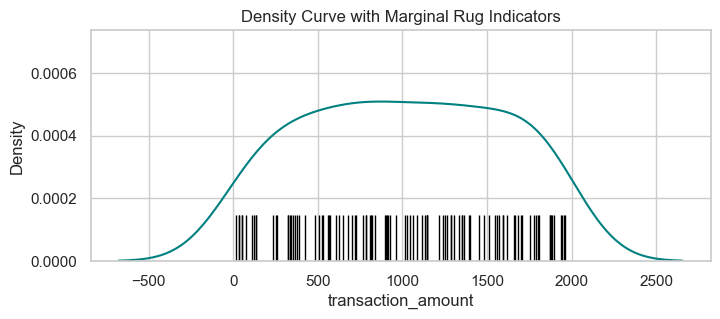

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.kdeplot(df['transaction_amount'].head(100), ax=ax, color='teal')
sns.rugplot(df['transaction_amount'].head(100), ax=ax, color='black', height=0.2)
ax.set_title('Density Curve with Marginal Rug Indicators')
plt.show()

### Categorical Boxplots: `sns.boxplot()`
**Explanation**: Visualizes quartiles, median, and IQR outlier boundaries across card types.

**Syntax**: `sns.boxplot(df, x='card_type', y='transaction_amount', hue='is_fraud')`

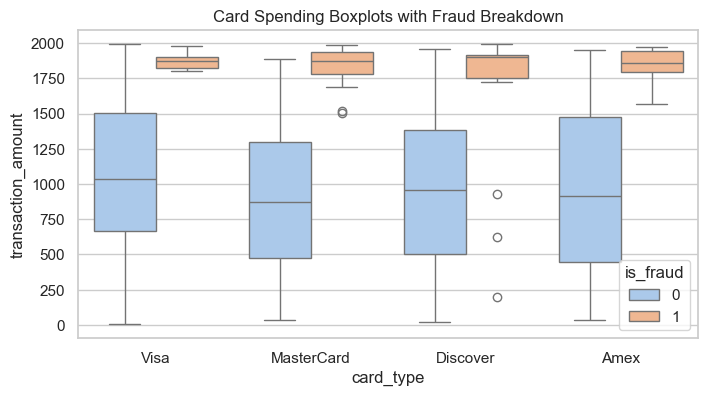

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', palette='pastel', ax=ax)
ax.set_title('Card Spending Boxplots with Fraud Breakdown')
plt.show()

### Violin Distribution: `sns.violinplot()`
**Explanation**: Combines boxplot quartiles with mirrored KDE density curves.

**Syntax**: `sns.violinplot(df, x='card_type', y='transaction_amount', split=True)`

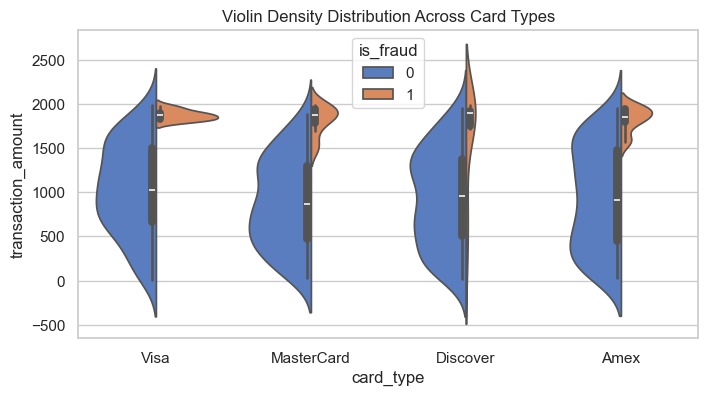

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', split=True, palette='muted', ax=ax)
ax.set_title('Violin Density Distribution Across Card Types')
plt.show()

### Categorical Scatter: `sns.stripplot()`
**Explanation**: Draws raw point jitter across categorical buckets.

**Syntax**: `sns.stripplot(df, x='region', y='transaction_amount', jitter=True)`

<string>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




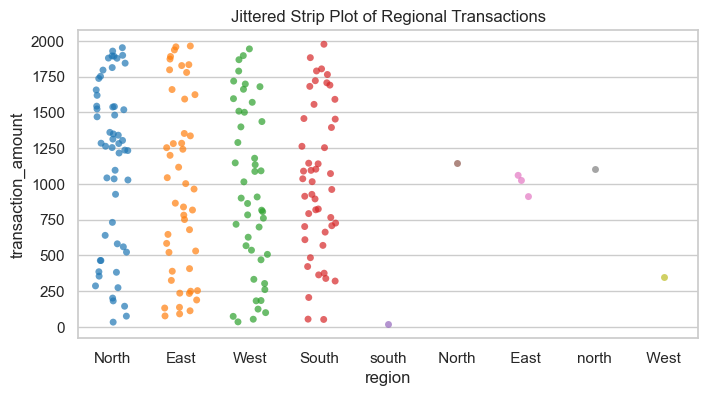

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(df.head(200), x='region', y='transaction_amount', jitter=0.25, alpha=0.7, palette='tab10', ax=ax)
ax.set_title('Jittered Strip Plot of Regional Transactions')
plt.show()

### Non-Overlapping Swarms: `sns.swarmplot()`
**Explanation**: Arranges points along categorical axes preventing overlap.

**Syntax**: `sns.swarmplot(df.head(100), x='region', y='transaction_amount')`

<string>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




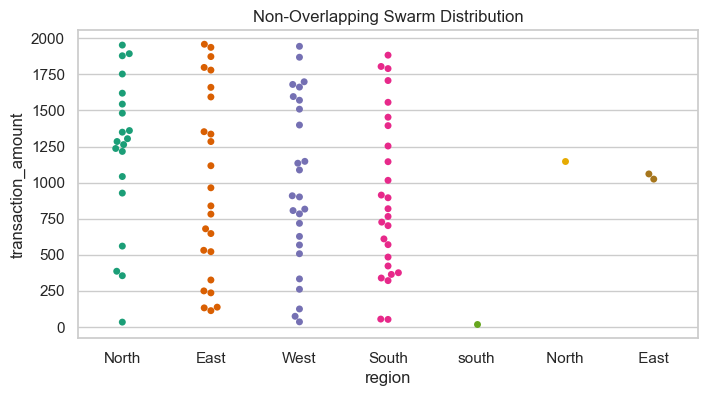

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.swarmplot(df.head(100), x='region', y='transaction_amount', palette='Dark2', size=5, ax=ax)
ax.set_title('Non-Overlapping Swarm Distribution')
plt.show()

### Categorical Aggregation: `sns.barplot()`
**Explanation**: Computes mean estimates with bootstrapping 95% confidence intervals.

**Syntax**: `sns.barplot(df, x='region', y='transaction_amount', hue='is_fraud')`

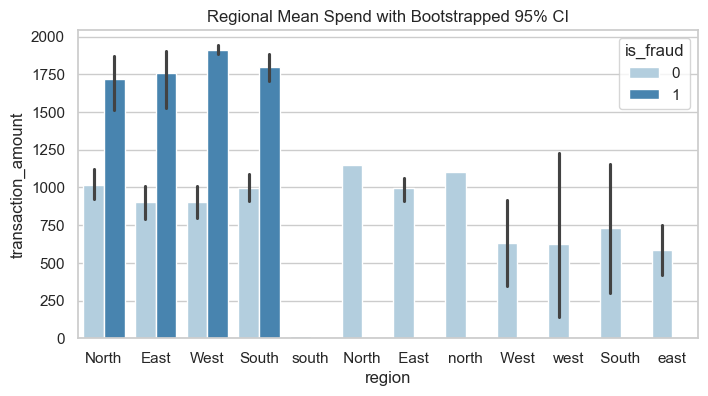

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(df.head(500), x='region', y='transaction_amount', hue='is_fraud', palette='Blues', ax=ax)
ax.set_title('Regional Mean Spend with Bootstrapped 95% CI')
plt.show()

### Relationship Scatter: `sns.scatterplot()`
**Explanation**: Maps bivariate relationships with multi-variable hue, size, and style encodings.

**Syntax**: `sns.scatterplot(df, x='account_age_months', y='transaction_amount', hue='card_type')`

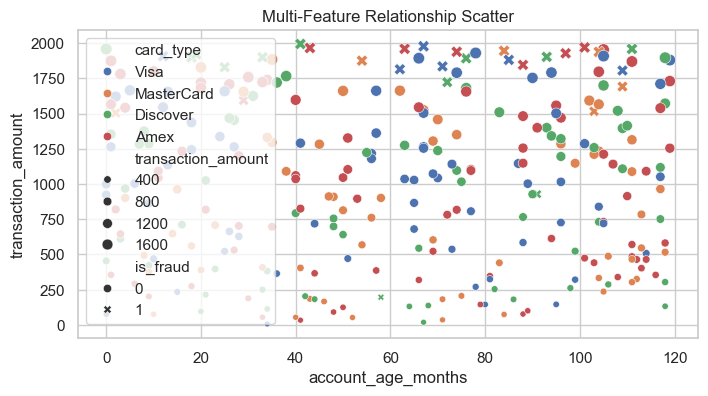

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(df.head(300), x='account_age_months', y='transaction_amount', hue='card_type', style='is_fraud', size='transaction_amount', ax=ax)
ax.set_title('Multi-Feature Relationship Scatter')
plt.show()

### Relationship Trends: `sns.lineplot()`
**Explanation**: Aggregates repeated observations displaying mean trends and confidence interval bands.

**Syntax**: `sns.lineplot(df, x='account_age_months', y='transaction_amount')`

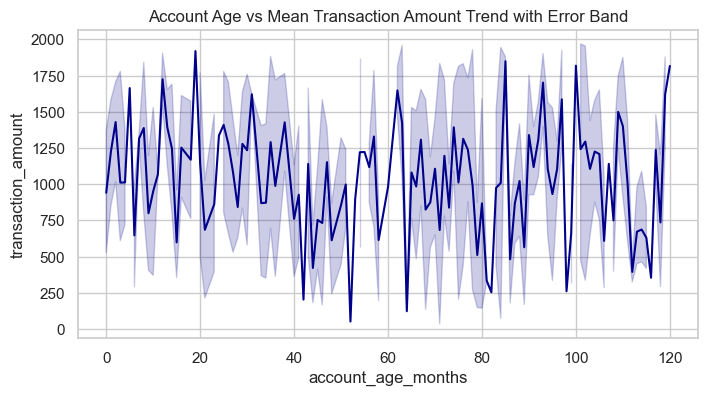

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(df.head(400), x='account_age_months', y='transaction_amount', color='darkblue', ax=ax)
ax.set_title('Account Age vs Mean Transaction Amount Trend with Error Band')
plt.show()

### Regression Overlay: `sns.regplot()`
**Explanation**: Plots linear regression fit trendline with shaded confidence intervals.

**Syntax**: `sns.regplot(df, x='account_age_months', y='transaction_amount')`

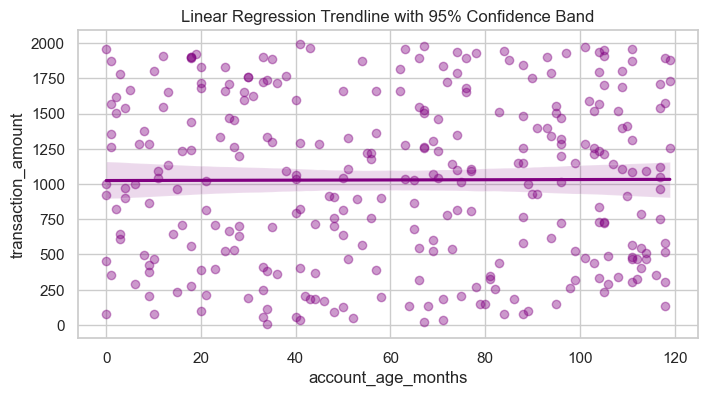

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.regplot(df.head(300), x='account_age_months', y='transaction_amount', color='purple', scatter_kws={'alpha':0.4}, ax=ax)
ax.set_title('Linear Regression Trendline with 95% Confidence Band')
plt.show()

### Figure-Level Distribution: `sns.displot()`
**Explanation**: FacetGrid wrapper managing multi-panel distribution layouts across columns.

**Syntax**: `sns.displot(df, x='transaction_amount', col='region')`

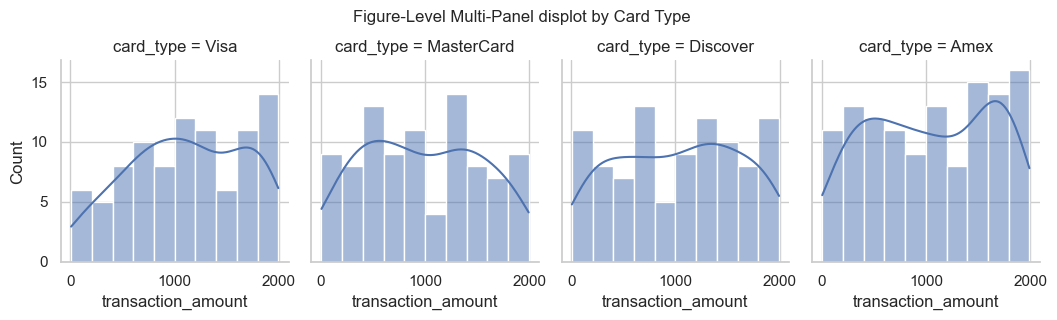

In [14]:
g = sns.displot(df.head(400), x='transaction_amount', col='card_type', kde=True, height=3, aspect=0.9)
g.fig.suptitle('Figure-Level Multi-Panel displot by Card Type', y=1.05)
plt.show()

### Figure-Level Relationships: `sns.relplot()`
**Explanation**: FacetGrid wrapper structuring relational plots across subplots.

**Syntax**: `sns.relplot(df, x='account_age_months', y='transaction_amount', col='region')`

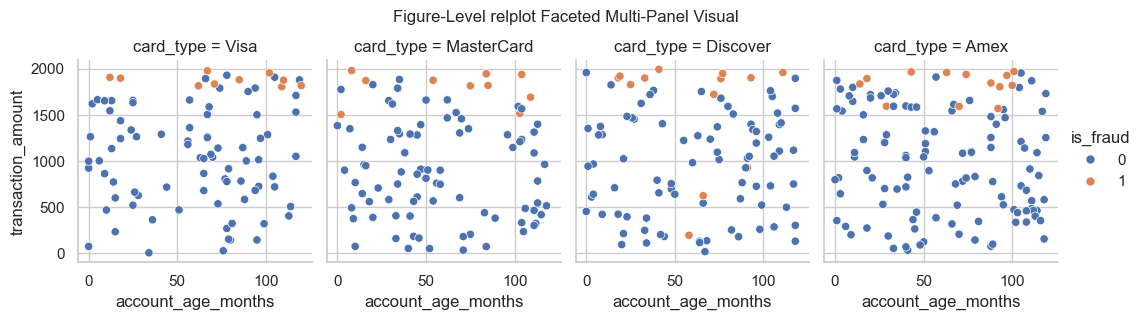

In [15]:
g = sns.relplot(df.head(400), x='account_age_months', y='transaction_amount', col='card_type', hue='is_fraud', height=3, aspect=0.9)
g.fig.suptitle('Figure-Level relplot Faceted Multi-Panel Visual', y=1.05)
plt.show()

### Figure-Level Categoricals: `sns.catplot()`
**Explanation**: FacetGrid wrapper rendering categorical plots across multi-panel facets.

**Syntax**: `sns.catplot(df, x='region', y='transaction_amount', kind='box')`

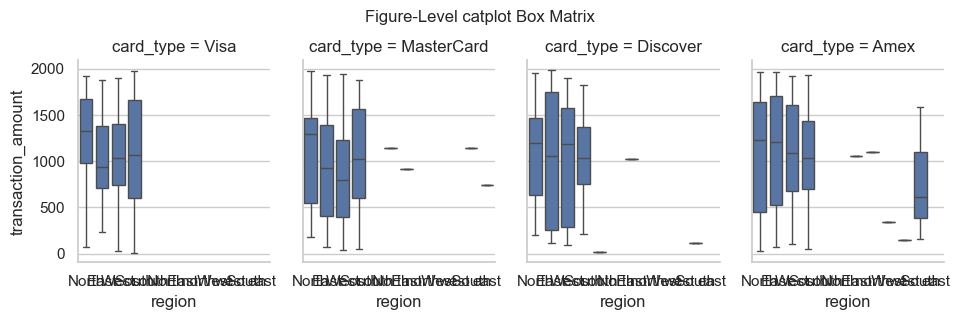

In [16]:
g = sns.catplot(df.head(400), x='region', y='transaction_amount', kind='box', col='card_type', height=3, aspect=0.8)
g.fig.suptitle('Figure-Level catplot Box Matrix', y=1.05)
plt.show()

## Section: Senior Fintech Interview Scenarios (5+ Years Experience)

### Q1: Axes-Level vs Figure-Level Functions in Seaborn
**Explanation**: Explain differences: Axes-level functions (`sns.histplot`, `sns.boxplot`) draw onto a specific `ax` and return an `Axes` object. Figure-level functions (`sns.displot`, `sns.catplot`) control the entire figure via `FacetGrid`.

**Syntax**: `ax = sns.histplot(ax=ax)` vs `g = sns.displot()`

In [17]:
print('Axes-level: integrates with custom subplots. Figure-level: automated multi-panel facet management.')

Axes-level: integrates with custom subplots. Figure-level: automated multi-panel facet management.
